# Sit.2 — GeoVision-CLIP (clasificador RemoteCLIP + LoRA)

| Enfoque | Metrica | KPI 0.45 |
|---------|---------|----------|
| **Este notebook** | Clasificacion 5 clases | Si (~0.44-0.48) |
| `notebookresultados_*` | Retrieval imagen-texto CLIP | No (~0.11 R@1) |

Entrena **solo CE** (clasificador 5 clases), como el notebook que alcanza ~0.45. InfoNCE no entrena el visual.

Por época: loss CE, accuracy, **Recall@1 y @5**.

**Salidas:** `best.pt`, `training_history.json`, `training_curves.png`, `curvas/`, Drive.


In [1]:
# @title Dependencias
%pip install -q huggingface_hub open_clip_torch zarr numcodecs pandas pyarrow numpy tqdm matplotlib
%pip install -q torch torchvision

# Silenciar warnings ruidosos (entrenamiento + HF + open_clip)
import logging
import os
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*TypedStorage is deprecated.*")
warnings.filterwarnings("ignore", message=".*torch.cuda.amp.autocast.*")
warnings.filterwarnings("ignore", message=".*weights_only.*")

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("PYTHONWARNINGS", "ignore::FutureWarning,ignore::DeprecationWarning")

for _log in (
    "open_clip", "timm", "urllib3", "huggingface_hub", "filelock",
    "torch", "torchvision", "google", "google.auth",
):
    logging.getLogger(_log).setLevel(logging.ERROR)

import torch
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


## 1. Descarga dataset (Hugging Face)

Repo: `Slucu-0310/geovision-cali-sit2`

In [2]:
# @title HF descarga
import os
from pathlib import Path
HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"
def _find():
    for p in [Path("/content/dataset_sit2"), Path("dataset_sit2")]:
        if (p/"metadatos.parquet").is_file() and (p/"tiles.zarr").exists(): return p
    return Path("/content/dataset_sit2")
DATA_DIR = _find()
if not (DATA_DIR/"metadatos.parquet").is_file():
    try:
        from google.colab import userdata
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except Exception: pass
    from huggingface_hub import login, snapshot_download
    if os.environ.get("HF_TOKEN"): login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
    DATA_DIR = Path("/content/dataset_sit2")
    snapshot_download(repo_id=HF_REPO_ID, repo_type="dataset", local_dir=str(DATA_DIR), local_dir_use_symlinks=False)
print("DATA_DIR:", DATA_DIR)


Fetching 43 files:   0%|          | 0/43 [00:00<?, ?it/s]

DATA_DIR: /content/dataset_sit2


## 2. Cargar tiles Zarr + parquet

In [3]:
# @title Cargar datos
import json
import numpy as np
import pandas as pd
import zarr

SEED = 42
CLASES = [
    "contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
    "vegetacion_densa", "suelo_urbano",
]


def _zarr_store(path: str):
    try:
        return zarr.storage.LocalStore(path)
    except AttributeError:
        return zarr.DirectoryStore(path)


def open_tiles_zarr(zarr_path):
    """Abre tiles.zarr: array raiz (N,13,64,64) o grupo con clave 'tiles'."""
    p = str(zarr_path)
    try:
        root = zarr.open(p, mode="r")
    except Exception:
        root = zarr.open(_zarr_store(p), mode="r")

    # Zarr v3: el store puede ser un Array directamente (no usar `"tiles" in root`)
    if isinstance(root, zarr.Array):
        return root

    keys = list(root.array_keys()) if hasattr(root, "array_keys") else list(root.keys())
    if "tiles" in keys:
        return root["tiles"]

    arrays = list(root.arrays())
    if arrays:
        return arrays[0][1]

    raise ValueError(f"No se encontro array de tiles en {p}")


META_PATH = DATA_DIR / "metadatos.parquet"
ZARR_PATH = DATA_DIR / "tiles.zarr"
df = pd.read_parquet(META_PATH)
tiles_z = open_tiles_zarr(ZARR_PATH)

# Alinear indice parquet con filas del zarr (0 .. N-1)
if not np.issubdtype(df.index.dtype, np.integer):
    df = df.reset_index(drop=True)

n_zarr = int(tiles_z.shape[0])
if len(df) != n_zarr:
    print(f"AVISO: parquet {len(df)} filas vs zarr {n_zarr}; se trunca al minimo")
    n = min(len(df), n_zarr)
    df = df.iloc[:n].copy()
    tiles_z = tiles_z[:n]

print("tiles_z:", tiles_z.shape, "| parquet:", len(df))
if "split" in df.columns:
    print(df["split"].value_counts())


tiles_z: (2263, 13, 64, 64) | parquet: 2263
split
train    1584
test      340
val       339
Name: count, dtype: int64


## 3. Configuracion

RemoteCLIP + conv1 12ch + LoRA visual + **Linear(5 clases)**.


In [4]:
# @title Config
from sklearn.model_selection import train_test_split
import torch
from pathlib import Path
import numpy as np
np.random.seed(SEED); torch.manual_seed(SEED)
BATCH_SIZE,EPOCHS,LR,WEIGHT_DECAY=32,20,1e-5,0.2
LORA_RANK,LORA_VISUAL_FROM=8,6
TEXT_COL="descripcion"
TRAIN_INFONCE=False
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASE_A_IDX={c:i for i,c in enumerate(CLASES)}
KPI_RECALL1_MIN,KPI_RECALL5_MIN=0.45,0.70
RUN_DIR=Path("/content/runs/sit2_recall_final")
CURVAS_DIR=RUN_DIR/"curvas"
for _d in (RUN_DIR, CURVAS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
if "split" not in df.columns:
    ti,tmp=train_test_split(np.arange(len(df)),test_size=0.3,stratify=df["clase"],random_state=SEED)
    vi,te=train_test_split(tmp,test_size=0.5,stratify=df.iloc[tmp]["clase"],random_state=SEED)
    df["split"]="train"; df.loc[vi,"split"]="val"; df.loc[te,"split"]="test"
print(df["split"].value_counts())


split
train    1584
test      340
val       339
Name: count, dtype: int64


## 4. Entrenamiento

- **Loss de entrenamiento** = solo cross-entropy.
- **Métricas por época**: loss CE, val accuracy, Recall@1 y Recall@5.


In [5]:
# @title Entrenar RemoteCLIP + LoRA + clasificador
import warnings
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
import random, json
from tqdm.auto import tqdm
import open_clip
from huggingface_hub import hf_hub_download

rng = np.random.default_rng(SEED)
ix = rng.choice(int(tiles_z.shape[0]), min(512, int(tiles_z.shape[0])), replace=False)
sm = np.stack([np.asarray(tiles_z[i], dtype=np.float32) for i in ix])
bm, bs = sm.mean((0,2,3)).astype(np.float32), np.maximum(sm.std((0,2,3)), 1e-3).astype(np.float32)


class Dset(torch.utils.data.Dataset):
    """Tiles + etiqueta de clase."""
    def __init__(self, df, z, sp, augment=False):
        self.df = df[df["split"] == sp]
        self.z = z
        self.augment = augment
        self.m = torch.from_numpy(bm).view(13, 1, 1).float()
        self.s = torch.from_numpy(bs).view(13, 1, 1).float().clamp(min=1e-6)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        z_idx = int(self.df.index[i])
        t = torch.from_numpy(np.asarray(self.z[z_idx], dtype=np.float32))
        t = torch.clamp((t - self.m) / self.s, -3, 3)[:12]
        if self.augment:
            if torch.rand(1).item() > 0.5:
                t = torch.flip(t, [-1])
            t = torch.rot90(t, torch.randint(0, 4, (1,)).item(), [-2, -1])
        lbl = CLASE_A_IDX[r["clase"]]
        return t, lbl


ds_tr = Dset(df, tiles_z, "train", augment=True)
ds_va = Dset(df, tiles_z, "val", augment=False)
ds_te = Dset(df, tiles_z, "test", augment=False)

tr_ld = torch.utils.data.DataLoader(ds_tr, BATCH_SIZE, shuffle=True, num_workers=0)
va_ld = torch.utils.data.DataLoader(ds_va, BATCH_SIZE, shuffle=False, num_workers=0)
te_ld = torch.utils.data.DataLoader(ds_te, BATCH_SIZE, shuffle=False, num_workers=0)
print("Entrenamiento: solo CE | Metricas: accuracy, Recall@1, Recall@5")

class LoRALinear(nn.Module):
    def __init__(self, lin, rank=8):
        super().__init__()
        o,i = lin.weight.shape
        self.register_buffer("weight", lin.weight.data.clone())
        if lin.bias is not None: self.register_buffer("bias", lin.bias.data.clone())
        self.lora_A = nn.Parameter(torch.randn(o,rank)*0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank,i))
    def forward(self,x):
        b = F.linear(x, self.weight, getattr(self,"bias",None))
        return b + F.linear(x, self.lora_A @ self.lora_B)

def alora(m,r=8):
    for n,c in m.named_children():
        if isinstance(c,nn.Linear) and n in {"out_proj","c_fc","c_proj"}: setattr(m,n,LoRALinear(c,r))
        else: alora(c,r)

cm,_,_ = open_clip.create_model_and_transforms("ViT-B-32", pretrained=None)
cp = hf_hub_download("chendelong/RemoteCLIP","RemoteCLIP-ViT-B-32.pt", cache_dir="/content/checkpoints")
cm.load_state_dict(torch.load(cp, map_location="cpu", weights_only=True), strict=False)
oc, nc = cm.visual.conv1, nn.Conv2d(12, cm.visual.conv1.out_channels, cm.visual.conv1.kernel_size, stride=cm.visual.conv1.stride, padding=cm.visual.conv1.padding, bias=False)
with torch.no_grad():
    w=nc.weight.data; w[:,3],w[:,2],w[:,1]=oc.weight[:,0],oc.weight[:,1],oc.weight[:,2]
    wm=oc.weight.mean(1,keepdim=False)
    for b in range(12):
        if b not in (3,2,1): w[:,b]=wm*(3/12)
    nc.weight.copy_(w)
cm.visual.conv1 = nc
for p in cm.parameters(): p.requires_grad=False
alora(cm.visual.transformer.resblocks[LORA_VISUAL_FROM:], LORA_RANK)
for n,p in cm.visual.named_parameters():
    if "ln_post" in n or "proj" in n: p.requires_grad=True

clf = nn.Linear(512, len(CLASES)).to(DEVICE)
cw = torch.tensor([len(ds_tr)/(len(CLASES)*max(1,(ds_tr.df["clase"]==c).sum())) for c in CLASES], device=DEVICE, dtype=torch.float32)
crit = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

def _visual_feats(tiles):
    x = F.interpolate(tiles, (224, 224), mode="bilinear", align_corners=False)
    return cm.visual(x).float()

@torch.no_grad()
def recall_at_k(loader, k=1):
    """Recall@k sobre prototipos del clasificador (5 clases)."""
    proto = F.normalize(clf.weight, dim=-1)
    hits = n = 0
    for tiles, lbl in loader:
        tiles, lbl = tiles.to(DEVICE), lbl.to(DEVICE)
        x = F.interpolate(tiles, (224, 224), mode="bilinear", align_corners=False)
        ei = F.normalize(cm.visual(x).float(), dim=-1)
        sim = ei @ proto.T
        kk = min(k, sim.size(1))
        topk = sim.topk(kk, dim=1).indices
        hits += (topk == lbl.unsqueeze(1)).any(dim=1).sum().item()
        n += len(lbl)
    return hits / max(n, 1)

cm, clf = cm.to(DEVICE), clf.to(DEVICE)
opt = torch.optim.AdamW(
    [p for p in cm.parameters() if p.requires_grad] + list(clf.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

best_acc, history = 0.0, []
for ep in range(EPOCHS):
    cm.train(); clf.train()
    train_loss, nb_tr = 0.0, 0
    for tiles, lbl in tqdm(tr_ld, desc=f"Ep{ep} train", leave=False):
        tiles, lbl = tiles.to(DEVICE), lbl.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
            loss = crit(clf(_visual_feats(tiles)), lbl)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item()
        nb_tr += 1
    sched.step()

    cm.eval(); clf.eval()
    val_loss, cor, tot, nb_va = 0.0, 0, 0, 0
    with torch.no_grad():
        for tiles, lbl in va_ld:
            tiles, lbl = tiles.to(DEVICE), lbl.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
                e_img = _visual_feats(tiles)
                loss = crit(clf(e_img), lbl)
            val_loss += loss.item()
            cor += (clf(e_img).argmax(1) == lbl).sum().item()
            tot += len(lbl)
            nb_va += 1

    vacc = cor / max(tot, 1)
    va_r1 = recall_at_k(va_ld, k=1)
    va_r5 = recall_at_k(va_ld, k=5)

    row = {
        "epoch": ep,
        "train_loss_ce": train_loss / max(nb_tr, 1),
        "val_loss_ce": val_loss / max(nb_va, 1),
        "val_acc": vacc,
        "val_recall_at_1": va_r1,
        "val_recall_at_5": va_r5,
    }
    history.append(row)

    if vacc > best_acc:
        best_acc = vacc
        torch.save({
            "cm": cm.state_dict(), "clf": clf.state_dict(),
            "acc": vacc, "epoch": ep,
            "val_recall_at_1": va_r1, "val_recall_at_5": va_r5,
        }, RUN_DIR / "best.pt")

    print(
        f"Ep{ep} train_CE={row['train_loss_ce']:.4f} val_CE={row['val_loss_ce']:.4f} "
        f"acc={vacc:.4f} | R@1={va_r1:.4f} R@5={va_r5:.4f}"
        + (" *" if vacc >= best_acc else "")
    )

ck=torch.load(RUN_DIR/"best.pt", map_location="cpu", weights_only=False)
cm.load_state_dict(ck["cm"]); clf.load_state_dict(ck["clf"])
cm.eval(); clf.eval()
cor = tot = 0
with torch.no_grad():
    for tiles, lbl in te_ld:
        tiles, lbl = tiles.to(DEVICE), lbl.to(DEVICE)
        cor += (clf(_visual_feats(tiles)).argmax(1) == lbl).sum().item()
        tot += len(lbl)
test_acc = cor / max(tot, 1)
test_r1 = recall_at_k(te_ld, k=1)
test_r5 = recall_at_k(te_ld, k=5)

METRICAS = {
    "best_val_accuracy": float(ck["acc"]),
    "test_accuracy": float(test_acc),
    "test_recall_at_1": float(test_r1),
    "test_recall_at_5": float(test_r5),
    "kpi_recall_at_1_min": KPI_RECALL1_MIN,
    "kpi_recall_at_5_min": KPI_RECALL5_MIN,
    "arquitectura": "RemoteCLIP+LoRA+Linear5 (solo CE, como notebook bueno)",
}
HISTORY_PATH = RUN_DIR / "training_history.json"
HISTORY_PATH.write_text(json.dumps(history, indent=2), encoding="utf-8")
(RUN_DIR/"training_logs.json").write_text(
    json.dumps({"history": history, "metricas": METRICAS}, indent=2),
    encoding="utf-8",
)
print("Historial:", HISTORY_PATH, f"({len(history)} epocas)")
print("Val acc:", METRICAS["best_val_accuracy"], "| Test acc:", METRICAS["test_accuracy"])
print("Test Recall@1:", test_r1, "| Recall@5:", test_r5)


Entrenamiento: solo CE | Metricas: accuracy, Recall@1, Recall@5


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Ep0 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep0 train_CE=1.5483 val_CE=1.4804 acc=0.3628 | R@1=0.3628 R@5=1.0000 *


Ep1 train:   0%|          | 0/50 [00:00<?, ?it/s]

...

Ep17 train_CE=0.5338 val_CE=1.7178 acc=0.3717 | R@1=0.3687 R@5=1.0000


Ep18 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep18 train_CE=0.5153 val_CE=1.7389 acc=0.3658 | R@1=0.3717 R@5=1.0000


Ep19 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep19 train_CE=0.5114 val_CE=1.7130 acc=0.3864 | R@1=0.3776 R@5=1.0000
Historial: /content/runs/sit2_recall_final/training_history.json (20 epocas)
Val acc: 0.4336283185840708 | Test acc: 0.47352941176470587
Test Recall@1: 0.4676470588235294 | Recall@5: 1.0


## 4b. Curvas de entrenamiento (por época)

Resumen: /content/runs/sit2_recall_final/training_curves.png
Curvas por metrica en: /content/runs/sit2_recall_final/curvas
Archivos: ['curva_loss_ce.png', 'curva_metricas.png', 'curva_recall.png']


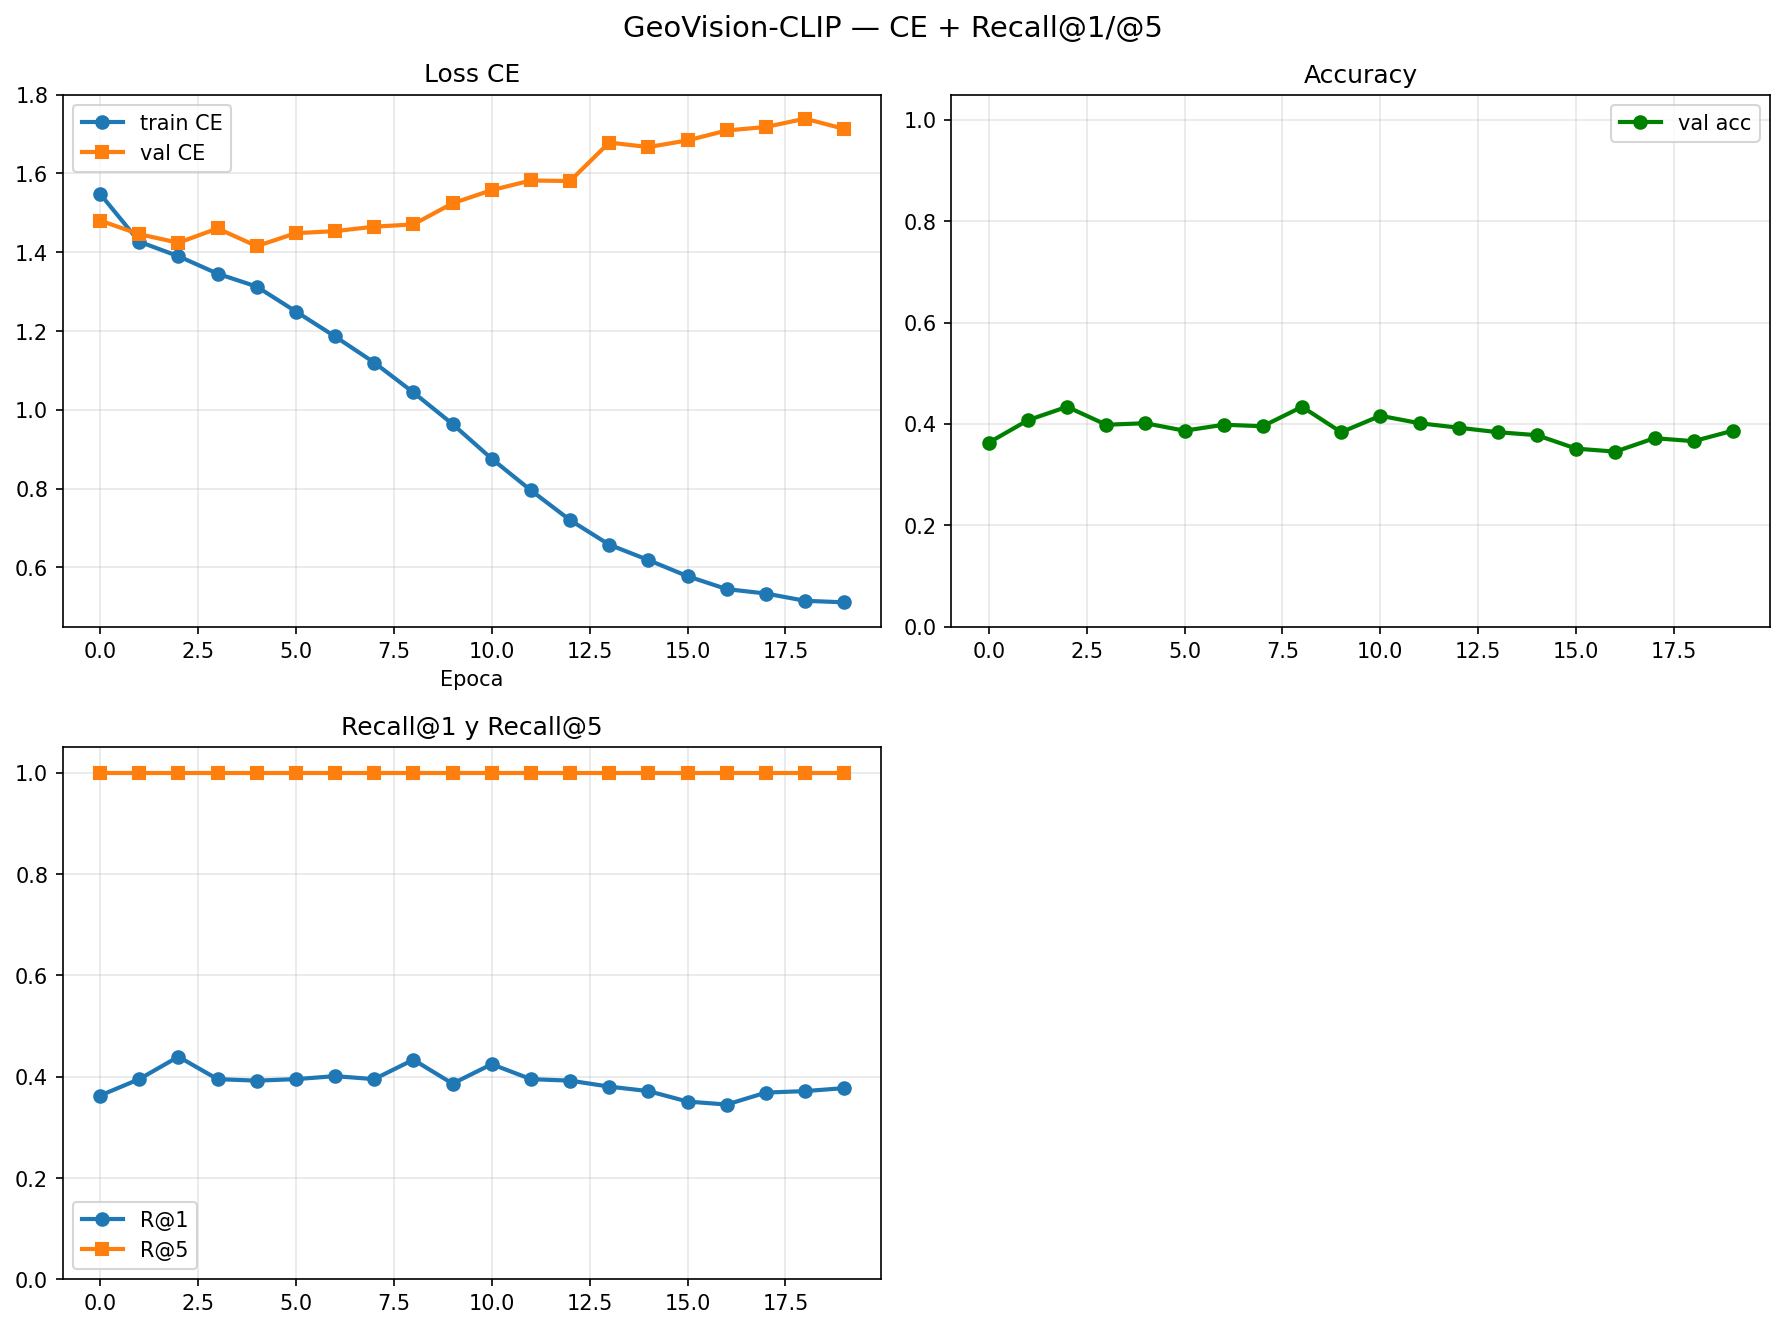

In [6]:
# @title Graficas: loss CE, accuracy, Recall@1 y Recall@5
import json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

def _cargar_history():
    if "history" in globals() and history:
        return history
    for p in (
        RUN_DIR / "training_history.json",
        RUN_DIR / "training_logs.json",
    ):
        if p.is_file():
            data = json.loads(p.read_text(encoding="utf-8"))
            return data if isinstance(data, list) else data.get("history", [])
    raise FileNotFoundError(
        "No hay historial. Ejecuta la celda de entrenamiento o coloca "
        "training_history.json en " + str(RUN_DIR)
    )

def graficar_curvas_entrenamiento(hist_list, out_dir=None, kpi1=None, kpi5=None):
    out_dir = Path(out_dir or CURVAS_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    kpi1 = kpi1 if kpi1 is not None else KPI_RECALL1_MIN
    kpi5 = kpi5 if kpi5 is not None else KPI_RECALL5_MIN

    hist = pd.DataFrame(hist_list)
    epochs = hist["epoch"]

    series = [("loss_ce", "Loss cross-entropy (5 clases)", "train_loss_ce", "val_loss_ce")]
    for slug, title, col_tr, col_va in series:
        if col_tr not in hist.columns:
            continue
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(epochs, hist[col_tr], "o-", label="train", linewidth=2)
        ax.plot(epochs, hist[col_va], "s-", label="val", linewidth=2)
        ax.set_xlabel("Epoca"); ax.set_ylabel(title)
        ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(out_dir / f"curva_{slug}.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    # Recall@1 y Recall@5
    if "val_recall_at_1" in hist.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(epochs, hist["val_recall_at_1"], "o-", label="val R@1", linewidth=2)
        ax.plot(epochs, hist["val_recall_at_5"], "s-", label="val R@5", linewidth=2)
        ax.set_xlabel("Epoca"); ax.set_ylabel("Recall")
        ax.set_title("Recall@1 y Recall@5"); ax.set_ylim(0, 1.05)
        ax.legend(); ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(out_dir / "curva_recall.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, hist["val_acc"], "o-", label="val accuracy", linewidth=2)
    ax.set_xlabel("Epoca"); ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy validacion"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_dir / "curva_metricas.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("GeoVision-CLIP — CE + Recall@1/@5", fontsize=14)
    ax = axes[0, 0]
    if "train_loss_ce" in hist.columns:
        ax.plot(epochs, hist["train_loss_ce"], "o-", label="train CE", linewidth=2)
        ax.plot(epochs, hist["val_loss_ce"], "s-", label="val CE", linewidth=2)
    ax.set_title("Loss CE"); ax.set_xlabel("Epoca"); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(epochs, hist["val_acc"], "o-", label="val acc", linewidth=2, color="green")
    ax.set_title("Accuracy"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    if "val_recall_at_1" in hist.columns:
        ax.plot(epochs, hist["val_recall_at_1"], "o-", label="R@1", linewidth=2)
        ax.plot(epochs, hist["val_recall_at_5"], "s-", label="R@5", linewidth=2)
    ax.set_title("Recall@1 y Recall@5"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
    axes[1, 1].axis("off")
    fig.tight_layout()
    resumen = RUN_DIR / "training_curves.png"
    fig.savefig(resumen, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return resumen, out_dir

hist_loaded = _cargar_history()
resumen_path, curvas_dir = graficar_curvas_entrenamiento(hist_loaded)
print("Resumen:", resumen_path)
print("Curvas por metrica en:", curvas_dir)
print("Archivos:", sorted(p.name for p in curvas_dir.glob("*.png")))
try:
    from IPython.display import Image, display
    display(Image(filename=str(resumen_path)))
except Exception:
    pass

## 5. Recall@1 y Recall@5

**Recall@k:** top-k prototipos de clase más similares a la imagen. Acierto si la clase verdadera está en el top-k. Con 5 clases, R@5 suele ser ~1.0; R@1 ≈ accuracy.


## 6. Exportar pesos + SHA256 + Google Drive

In [7]:
# @title Exportar + SHA256 + Google Drive
import hashlib, json, shutil, os
from datetime import datetime, timezone
from pathlib import Path

OUT_DIR = Path("/content/geovision_clip_modelo_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT = RUN_DIR / "best.pt"
shutil.copy2(CKPT, OUT_DIR / "best.pt")

h = hashlib.sha256()
with open(CKPT, "rb") as f:
    for ch in iter(lambda: f.read(65536), b""): h.update(ch)
sha = h.hexdigest()
(OUT_DIR / "hashes.sha256").write_text(f"{sha}  best.pt\n", encoding="utf-8")

metricas = json.loads((RUN_DIR/"training_logs.json").read_text())["metricas"]
meta = {
    "modelo": "RemoteCLIP+LoRA+Linear5",
    "dataset": HF_REPO_ID,
    "clases": CLASES,
    "metricas": metricas,
    "sha256": sha,
    "fecha": datetime.now(timezone.utc).isoformat(),
}
(OUT_DIR / "metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
shutil.copy2(RUN_DIR/"training_logs.json", OUT_DIR/"training_logs.json")
if (RUN_DIR/"training_history.json").is_file():
    shutil.copy2(RUN_DIR/"training_history.json", OUT_DIR/"training_history.json")
if (RUN_DIR/"training_curves.png").is_file():
    shutil.copy2(RUN_DIR/"training_curves.png", OUT_DIR/"training_curves.png")
if CURVAS_DIR.is_dir():
    shutil.copytree(CURVAS_DIR, OUT_DIR/"curvas", dirs_exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    dest = Path("/content/drive/MyDrive/geovision-cali/sit2_geovision_clip")
    dest.mkdir(parents=True, exist_ok=True)
    for f in ("best.pt","metadata.json","hashes.sha256","training_logs.json",
              "training_history.json","training_curves.png"):
        src = OUT_DIR / f
        if src.is_file():
            shutil.copy2(src, dest / f)
    if (OUT_DIR / "curvas").is_dir():
        shutil.copytree(OUT_DIR / "curvas", dest / "curvas", dirs_exist_ok=True)
    print("Drive:", dest)
except Exception as e:
    print("Drive omitido:", e)

shutil.make_archive(str(OUT_DIR), "zip", str(OUT_DIR))
print("SHA256:", sha)
print("ZIP:", str(OUT_DIR)+".zip")


Mounted at /content/drive
Drive: /content/drive/MyDrive/geovision-cali/sit2_geovision_clip
SHA256: 2f65a2fd41447f58b1ef8c14daff574d63ebaa7e6c704887e3c031f8543a1715
ZIP: /content/geovision_clip_modelo_final.zip
